Selected timestep: 2017-08-26T02:30:00.000000000
Mean ΔP (%): -3.571895396781399
Max ΔP (%): 86.82771727176383
Min ΔP (%): -3156.6800220283694
Area with ΔP > 20%:
  2,532,021.81 m²
  2.5320 km²
  2.15% of valid model area


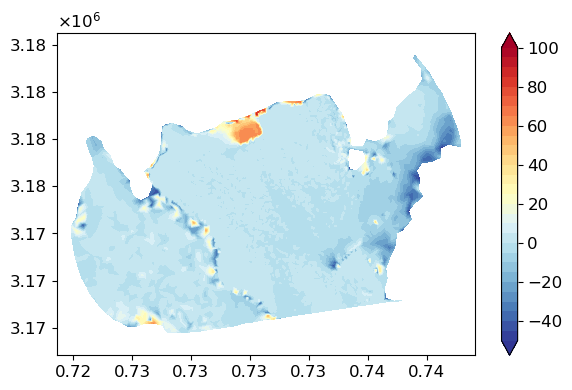

In [3]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
from matplotlib.ticker import FormatStrFormatter, FuncFormatter

# =========================
# File paths
# =========================
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Northside_barrier_reef_1.5m_v3.sw - Result Files\Northside_barrier_reef_1.5m_v3.dfsu"
dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

item_name = "Wave power, p"
target_time = np.datetime64("2017-08-26T02:30:00")

# =========================
# Open and read files
# =========================
dfs_reef = mikeio.open(dfsu_reef)
dfs_no_reef = mikeio.open(dfsu_no_reef)

ds_reef = dfs_reef.read(items=[item_name])
ds_no_reef = dfs_no_reef.read(items=[item_name])

p_reef_all = ds_reef[item_name]
p_no_reef_all = ds_no_reef[item_name]

geom_ref = p_no_reef_all.geometry
xy_ref = geom_ref.element_coordinates[:, :2]

elem_ids, weights = p_reef_all.geometry.get_2d_interpolant(
    xy_ref,
    n_nearest=3,
    extrapolate=False
)

def interp_reef_to_ref(da_reef_t):
    return da_reef_t.geometry.interp2d(
        da_reef_t,
        elem_ids,
        weights
    ).flatten()

# =========================
# Calculate ΔP
# =========================
time_index = np.argmin(np.abs(ds_no_reef.time.values - target_time))
selected_time = ds_no_reef.time.values[time_index]

p_no = p_no_reef_all.isel(time=time_index).to_numpy().flatten()
p_rf = interp_reef_to_ref(p_reef_all.isel(time=time_index))

p_no_safe = np.where(p_no > 1e-6, p_no, np.nan)

delta_p = ((p_no_safe - p_rf) / p_no_safe) * 100

print("Selected timestep:", selected_time)
print("Mean ΔP (%):", np.nanmean(delta_p))
print("Max ΔP (%):", np.nanmax(delta_p))
print("Min ΔP (%):", np.nanmin(delta_p))

# =========================
# Area where ΔP > 20%
# =========================
threshold = 20.0

# Element area from reference/no-reef mesh
element_area = geom_ref.get_element_area()

mask_gt20 = np.isfinite(delta_p) & (delta_p > threshold)

area_gt20_m2 = np.nansum(element_area[mask_gt20])
area_gt20_km2 = area_gt20_m2 / 1e6

total_valid_area_m2 = np.nansum(element_area[np.isfinite(delta_p)])
total_valid_area_km2 = total_valid_area_m2 / 1e6

percent_domain_gt20 = (area_gt20_m2 / total_valid_area_m2) * 100

print("Area with ΔP > 20%:")
print(f"  {area_gt20_m2:,.2f} m²")
print(f"  {area_gt20_km2:,.4f} km²")
print(f"  {percent_domain_gt20:.2f}% of valid model area")

# =========================
# Smooth spatial footprint plot
# =========================
x = xy_ref[:, 0]
y = xy_ref[:, 1]
z = delta_p.copy()

valid = np.isfinite(z)
valid &= (z >= -50) & (z <= 100)

x_valid = x[valid]
y_valid = y[valid]
z_valid = z[valid]

triang = tri.Triangulation(x_valid, y_valid)

triangles = triang.triangles
xtri = x_valid[triangles]
ytri = y_valid[triangles]

edge1 = np.sqrt((xtri[:, 0] - xtri[:, 1])**2 + (ytri[:, 0] - ytri[:, 1])**2)
edge2 = np.sqrt((xtri[:, 1] - xtri[:, 2])**2 + (ytri[:, 1] - ytri[:, 2])**2)
edge3 = np.sqrt((xtri[:, 2] - xtri[:, 0])**2 + (ytri[:, 2] - ytri[:, 0])**2)

max_edge = np.maximum.reduce([edge1, edge2, edge3])
triang.set_mask(max_edge > 600)

# =========================
# Plot
# =========================
tick_size = 12

plt.figure(figsize=(6, 4))

levels = np.linspace(-50, 100, 31)

cf = plt.tricontourf(
    triang,
    z_valid,
    levels=levels,
    cmap="RdYlBu_r",
    extend="both"
)

cbar = plt.colorbar(cf)
cbar.ax.tick_params(labelsize=tick_size)
cbar.ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
cbar.update_ticks()

ax = plt.gca()
ax.tick_params(axis="both", labelsize=tick_size)

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1e6:.2f}"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{y/1e6:.2f}"))

ax.text(
    0.0, 1.01,
    r"$\times10^{6}$",
    transform=ax.transAxes,
    fontsize=tick_size,
    ha="left",
    va="bottom"
)

plt.axis("equal")
plt.tight_layout()
plt.show()

Selected timestep: 2017-08-26T02:30:00.000000000
Mean ΔP (%): 38.995016832649235
Max ΔP (%): 95.89393304398935
Min ΔP (%): -827.1954734648469

Area with ΔP > 20% using reef mesh area:
  2,514,800.88 m²
  2.5148 km²
  2.14% of valid reef-mesh domain


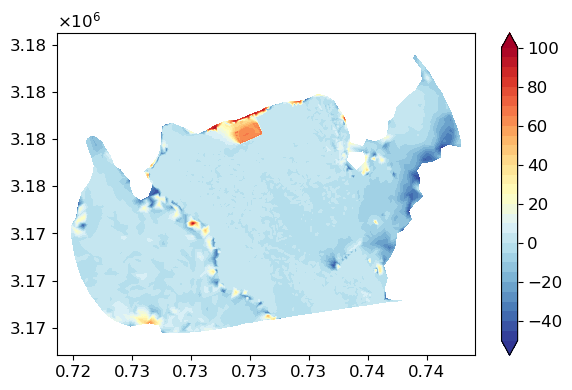

In [5]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
from matplotlib.ticker import FormatStrFormatter, FuncFormatter

# =========================
# File paths
# =========================
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Northside_barrier_reef_1.5m_v3.sw - Result Files\Northside_barrier_reef_1.5m_v3.dfsu"

dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

item_name = "Wave power, p"
target_time = np.datetime64("2017-08-26T02:30:00")

threshold = 20.0   # percent reduction threshold

# =========================
# Open and read files
# =========================
dfs_reef = mikeio.open(dfsu_reef)
dfs_no_reef = mikeio.open(dfsu_no_reef)

ds_reef = dfs_reef.read(items=[item_name])
ds_no_reef = dfs_no_reef.read(items=[item_name])

p_reef_all = ds_reef[item_name]
p_no_reef_all = ds_no_reef[item_name]

# =========================
# Use reef mesh as reference grid
# =========================
geom_reef = p_reef_all.geometry
xy_reef = geom_reef.element_coordinates[:, :2]

# Interpolate no-reef result onto reef mesh
elem_ids, weights = p_no_reef_all.geometry.get_2d_interpolant(
    xy_reef,
    n_nearest=3,
    extrapolate=False
)

def interp_no_reef_to_reef_mesh(da_no_reef_t):
    return da_no_reef_t.geometry.interp2d(
        da_no_reef_t,
        elem_ids,
        weights
    ).flatten()

# =========================
# Calculate ΔP on reef mesh
# =========================
time_index = np.argmin(np.abs(ds_reef.time.values - target_time))
selected_time = ds_reef.time.values[time_index]

p_rf = p_reef_all.isel(time=time_index).to_numpy().flatten()
p_no_interp = interp_no_reef_to_reef_mesh(
    p_no_reef_all.isel(time=time_index)
)

# Avoid division by zero
p_no_safe = np.where(p_no_interp > 1e-6, p_no_interp, np.nan)

# ΔP = (P_no_reef - P_reef) / P_no_reef * 100
delta_p = ((p_no_safe - p_rf) / p_no_safe) * 100

print("Selected timestep:", selected_time)
print("Mean ΔP (%):", np.nanmean(delta_p))
print("Max ΔP (%):", np.nanmax(delta_p))
print("Min ΔP (%):", np.nanmin(delta_p))

# =========================
# Area where ΔP > 20% using reef mesh element area
# =========================
element_area = geom_reef.get_element_area()

mask_gt20 = np.isfinite(delta_p) & (delta_p > threshold)

area_gt20_m2 = np.nansum(element_area[mask_gt20])
area_gt20_km2 = area_gt20_m2 / 1e6

total_valid_area_m2 = np.nansum(element_area[np.isfinite(delta_p)])
total_valid_area_km2 = total_valid_area_m2 / 1e6

percent_domain_gt20 = (area_gt20_m2 / total_valid_area_m2) * 100

print("\nArea with ΔP > 20% using reef mesh area:")
print(f"  {area_gt20_m2:,.2f} m²")
print(f"  {area_gt20_km2:,.4f} km²")
print(f"  {percent_domain_gt20:.2f}% of valid reef-mesh domain")

# =========================
# Smooth spatial footprint plot on reef mesh
# =========================
x = xy_reef[:, 0]
y = xy_reef[:, 1]
z = delta_p.copy()

valid = np.isfinite(z)
valid &= (z >= -50) & (z <= 100)

x_valid = x[valid]
y_valid = y[valid]
z_valid = z[valid]

triang = tri.Triangulation(x_valid, y_valid)

# Mask large triangles to avoid interpolation over land/gaps
triangles = triang.triangles

xtri = x_valid[triangles]
ytri = y_valid[triangles]

edge1 = np.sqrt((xtri[:, 0] - xtri[:, 1])**2 + (ytri[:, 0] - ytri[:, 1])**2)
edge2 = np.sqrt((xtri[:, 1] - xtri[:, 2])**2 + (ytri[:, 1] - ytri[:, 2])**2)
edge3 = np.sqrt((xtri[:, 2] - xtri[:, 0])**2 + (ytri[:, 2] - ytri[:, 0])**2)

max_edge = np.maximum.reduce([edge1, edge2, edge3])
triang.set_mask(max_edge > 600)

# =========================
# Plot
# =========================
tick_size = 12

plt.figure(figsize=(6, 4))

levels = np.linspace(-50, 100, 31)

cf = plt.tricontourf(
    triang,
    z_valid,
    levels=levels,
    cmap="RdYlBu_r",
    extend="both"
)

cbar = plt.colorbar(cf)
cbar.ax.tick_params(labelsize=tick_size)
cbar.ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
cbar.update_ticks()

ax = plt.gca()
ax.tick_params(axis="both", labelsize=tick_size)

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1e6:.2f}"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{y/1e6:.2f}"))

ax.text(
    0.0, 1.01,
    r"$\times10^{6}$",
    transform=ax.transAxes,
    fontsize=tick_size,
    ha="left",
    va="bottom"
)

plt.axis("equal")
plt.tight_layout()
plt.show()

Selected timestep: 2017-08-26T02:30:00.000000000
Mean ΔP (%): 38.995016832649235
Max ΔP (%): 95.89393304398935
Min ΔP (%): -827.1954734648469

Area with ΔP > 20% using reef mesh area:
  1,549,008.79 m²
  1.5490 km²
  1.32% of valid reef-mesh domain


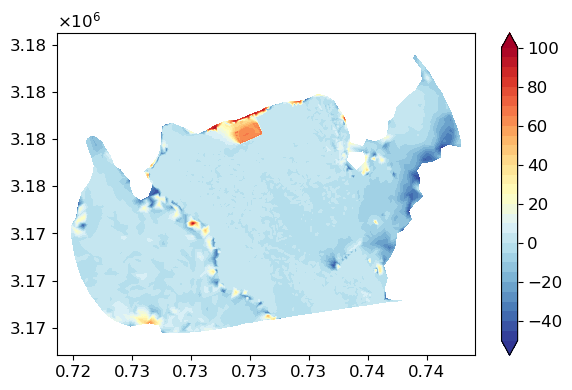

In [8]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
from matplotlib.ticker import FormatStrFormatter, FuncFormatter

# =========================
# File paths
# =========================
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Northside_barrier_reef_1.5m_v3.sw - Result Files\Northside_barrier_reef_1.5m_v3.dfsu"

dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

item_name = "Wave power, p"
target_time = np.datetime64("2017-08-26T02:30:00")

threshold = 30.0   # percent reduction threshold

# =========================
# Open and read files
# =========================
dfs_reef = mikeio.open(dfsu_reef)
dfs_no_reef = mikeio.open(dfsu_no_reef)

ds_reef = dfs_reef.read(items=[item_name])
ds_no_reef = dfs_no_reef.read(items=[item_name])

p_reef_all = ds_reef[item_name]
p_no_reef_all = ds_no_reef[item_name]

# =========================
# Use reef mesh as reference grid
# =========================
geom_reef = p_reef_all.geometry
xy_reef = geom_reef.element_coordinates[:, :2]

# Interpolate no-reef result onto reef mesh
elem_ids, weights = p_no_reef_all.geometry.get_2d_interpolant(
    xy_reef,
    n_nearest=3,
    extrapolate=False
)

def interp_no_reef_to_reef_mesh(da_no_reef_t):
    return da_no_reef_t.geometry.interp2d(
        da_no_reef_t,
        elem_ids,
        weights
    ).flatten()

# =========================
# Calculate ΔP on reef mesh
# =========================
time_index = np.argmin(np.abs(ds_reef.time.values - target_time))
selected_time = ds_reef.time.values[time_index]

p_rf = p_reef_all.isel(time=time_index).to_numpy().flatten()
p_no_interp = interp_no_reef_to_reef_mesh(
    p_no_reef_all.isel(time=time_index)
)

# Avoid division by zero
p_no_safe = np.where(p_no_interp > 1e-6, p_no_interp, np.nan)

# ΔP = (P_no_reef - P_reef) / P_no_reef * 100
delta_p = ((p_no_safe - p_rf) / p_no_safe) * 100

print("Selected timestep:", selected_time)
print("Mean ΔP (%):", np.nanmean(delta_p))
print("Max ΔP (%):", np.nanmax(delta_p))
print("Min ΔP (%):", np.nanmin(delta_p))

# =========================
# Area where ΔP > 20% using reef mesh element area
# =========================
element_area = geom_reef.get_element_area()

mask_gt20 = np.isfinite(delta_p) & (delta_p > threshold)

area_gt20_m2 = np.nansum(element_area[mask_gt20])
area_gt20_km2 = area_gt20_m2 / 1e6

total_valid_area_m2 = np.nansum(element_area[np.isfinite(delta_p)])
total_valid_area_km2 = total_valid_area_m2 / 1e6

percent_domain_gt20 = (area_gt20_m2 / total_valid_area_m2) * 100

print("\nArea with ΔP > 20% using reef mesh area:")
print(f"  {area_gt20_m2:,.2f} m²")
print(f"  {area_gt20_km2:,.4f} km²")
print(f"  {percent_domain_gt20:.2f}% of valid reef-mesh domain")

# =========================
# Smooth spatial footprint plot on reef mesh
# =========================
x = xy_reef[:, 0]
y = xy_reef[:, 1]
z = delta_p.copy()

valid = np.isfinite(z)
valid &= (z >= -50) & (z <= 100)

x_valid = x[valid]
y_valid = y[valid]
z_valid = z[valid]

triang = tri.Triangulation(x_valid, y_valid)

# Mask large triangles to avoid interpolation over land/gaps
triangles = triang.triangles

xtri = x_valid[triangles]
ytri = y_valid[triangles]

edge1 = np.sqrt((xtri[:, 0] - xtri[:, 1])**2 + (ytri[:, 0] - ytri[:, 1])**2)
edge2 = np.sqrt((xtri[:, 1] - xtri[:, 2])**2 + (ytri[:, 1] - ytri[:, 2])**2)
edge3 = np.sqrt((xtri[:, 2] - xtri[:, 0])**2 + (ytri[:, 2] - ytri[:, 0])**2)

max_edge = np.maximum.reduce([edge1, edge2, edge3])
triang.set_mask(max_edge > 600)

# =========================
# Plot
# =========================
tick_size = 12

plt.figure(figsize=(6, 4))

levels = np.linspace(-50, 100, 31)

cf = plt.tricontourf(
    triang,
    z_valid,
    levels=levels,
    cmap="RdYlBu_r",
    extend="both"
)

cbar = plt.colorbar(cf)
cbar.ax.tick_params(labelsize=tick_size)
cbar.ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
cbar.update_ticks()

ax = plt.gca()
ax.tick_params(axis="both", labelsize=tick_size)

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1e6:.2f}"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{y/1e6:.2f}"))

ax.text(
    0.0, 1.01,
    r"$\times10^{6}$",
    transform=ax.transAxes,
    fontsize=tick_size,
    ha="left",
    va="bottom"
)

plt.axis("equal")
plt.tight_layout()
plt.show()

Selected timestep: 2017-08-26T02:30:00.000000000
Mean ΔP (%): 38.995016832649235
Max ΔP (%): 95.89393304398935
Min ΔP (%): -827.1954734648469

Area with ΔP > 20% using reef mesh area:
  3,854,669.21 m²
  3.8547 km²
  3.28% of valid reef-mesh domain


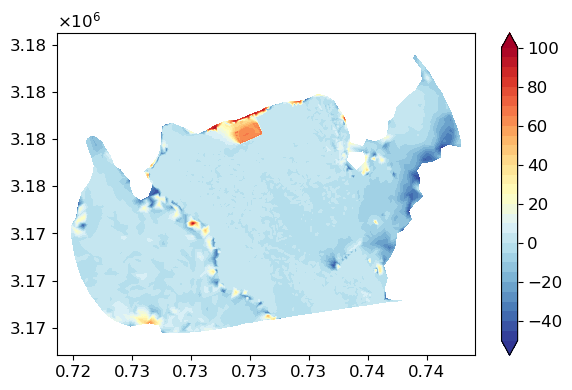

In [10]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
from matplotlib.ticker import FormatStrFormatter, FuncFormatter

# =========================
# File paths
# =========================
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Northside_barrier_reef_1.5m_v3.sw - Result Files\Northside_barrier_reef_1.5m_v3.dfsu"

dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

item_name = "Wave power, p"
target_time = np.datetime64("2017-08-26T02:30:00")

threshold = 10.0   # percent reduction threshold

# =========================
# Open and read files
# =========================
dfs_reef = mikeio.open(dfsu_reef)
dfs_no_reef = mikeio.open(dfsu_no_reef)

ds_reef = dfs_reef.read(items=[item_name])
ds_no_reef = dfs_no_reef.read(items=[item_name])

p_reef_all = ds_reef[item_name]
p_no_reef_all = ds_no_reef[item_name]

# =========================
# Use reef mesh as reference grid
# =========================
geom_reef = p_reef_all.geometry
xy_reef = geom_reef.element_coordinates[:, :2]

# Interpolate no-reef result onto reef mesh
elem_ids, weights = p_no_reef_all.geometry.get_2d_interpolant(
    xy_reef,
    n_nearest=3,
    extrapolate=False
)

def interp_no_reef_to_reef_mesh(da_no_reef_t):
    return da_no_reef_t.geometry.interp2d(
        da_no_reef_t,
        elem_ids,
        weights
    ).flatten()

# =========================
# Calculate ΔP on reef mesh
# =========================
time_index = np.argmin(np.abs(ds_reef.time.values - target_time))
selected_time = ds_reef.time.values[time_index]

p_rf = p_reef_all.isel(time=time_index).to_numpy().flatten()
p_no_interp = interp_no_reef_to_reef_mesh(
    p_no_reef_all.isel(time=time_index)
)

# Avoid division by zero
p_no_safe = np.where(p_no_interp > 1e-6, p_no_interp, np.nan)

# ΔP = (P_no_reef - P_reef) / P_no_reef * 100
delta_p = ((p_no_safe - p_rf) / p_no_safe) * 100

print("Selected timestep:", selected_time)
print("Mean ΔP (%):", np.nanmean(delta_p))
print("Max ΔP (%):", np.nanmax(delta_p))
print("Min ΔP (%):", np.nanmin(delta_p))

# =========================
# Area where ΔP > 20% using reef mesh element area
# =========================
element_area = geom_reef.get_element_area()

mask_gt20 = np.isfinite(delta_p) & (delta_p > threshold)

area_gt20_m2 = np.nansum(element_area[mask_gt20])
area_gt20_km2 = area_gt20_m2 / 1e6

total_valid_area_m2 = np.nansum(element_area[np.isfinite(delta_p)])
total_valid_area_km2 = total_valid_area_m2 / 1e6

percent_domain_gt20 = (area_gt20_m2 / total_valid_area_m2) * 100

print("\nArea with ΔP > 20% using reef mesh area:")
print(f"  {area_gt20_m2:,.2f} m²")
print(f"  {area_gt20_km2:,.4f} km²")
print(f"  {percent_domain_gt20:.2f}% of valid reef-mesh domain")

# =========================
# Smooth spatial footprint plot on reef mesh
# =========================
x = xy_reef[:, 0]
y = xy_reef[:, 1]
z = delta_p.copy()

valid = np.isfinite(z)
valid &= (z >= -50) & (z <= 100)

x_valid = x[valid]
y_valid = y[valid]
z_valid = z[valid]

triang = tri.Triangulation(x_valid, y_valid)

# Mask large triangles to avoid interpolation over land/gaps
triangles = triang.triangles

xtri = x_valid[triangles]
ytri = y_valid[triangles]

edge1 = np.sqrt((xtri[:, 0] - xtri[:, 1])**2 + (ytri[:, 0] - ytri[:, 1])**2)
edge2 = np.sqrt((xtri[:, 1] - xtri[:, 2])**2 + (ytri[:, 1] - ytri[:, 2])**2)
edge3 = np.sqrt((xtri[:, 2] - xtri[:, 0])**2 + (ytri[:, 2] - ytri[:, 0])**2)

max_edge = np.maximum.reduce([edge1, edge2, edge3])
triang.set_mask(max_edge > 600)

# =========================
# Plot
# =========================
tick_size = 12

plt.figure(figsize=(6, 4))

levels = np.linspace(-50, 100, 31)

cf = plt.tricontourf(
    triang,
    z_valid,
    levels=levels,
    cmap="RdYlBu_r",
    extend="both"
)

cbar = plt.colorbar(cf)
cbar.ax.tick_params(labelsize=tick_size)
cbar.ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
cbar.update_ticks()

ax = plt.gca()
ax.tick_params(axis="both", labelsize=tick_size)

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1e6:.2f}"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{y/1e6:.2f}"))

ax.text(
    0.0, 1.01,
    r"$\times10^{6}$",
    transform=ax.transAxes,
    fontsize=tick_size,
    ha="left",
    va="bottom"
)

plt.axis("equal")
plt.tight_layout()
plt.show()

Selected timestep: 2017-08-26T02:30:00.000000000
Mean ΔP (%): -5.789190720887949
Max ΔP (%): 93.01638411204077
Min ΔP (%): -2918.807940816834
Area with ΔP > 20%:
  2,442,656.78 m²
  2.4427 km²
  2.08% of valid model area


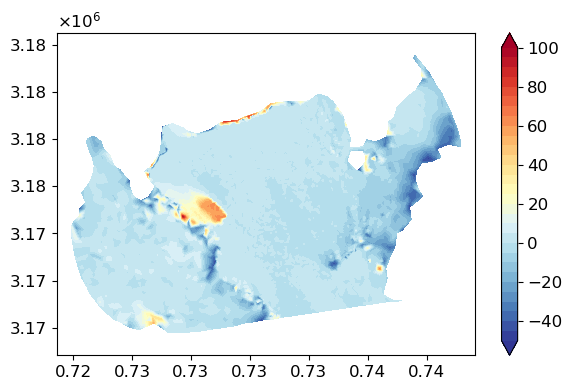

In [1]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
from matplotlib.ticker import FormatStrFormatter, FuncFormatter

# =========================
# File paths
# =========================
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_v2.sw - Result Files\west_side_barrier_reef_1.5m_v2.dfsu"
dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

item_name = "Wave power, p"
target_time = np.datetime64("2017-08-26T02:30:00")

# =========================
# Open and read files
# =========================
dfs_reef = mikeio.open(dfsu_reef)
dfs_no_reef = mikeio.open(dfsu_no_reef)

ds_reef = dfs_reef.read(items=[item_name])
ds_no_reef = dfs_no_reef.read(items=[item_name])

p_reef_all = ds_reef[item_name]
p_no_reef_all = ds_no_reef[item_name]

geom_ref = p_no_reef_all.geometry
xy_ref = geom_ref.element_coordinates[:, :2]

elem_ids, weights = p_reef_all.geometry.get_2d_interpolant(
    xy_ref,
    n_nearest=3,
    extrapolate=False
)

def interp_reef_to_ref(da_reef_t):
    return da_reef_t.geometry.interp2d(
        da_reef_t,
        elem_ids,
        weights
    ).flatten()

# =========================
# Calculate ΔP
# =========================
time_index = np.argmin(np.abs(ds_no_reef.time.values - target_time))
selected_time = ds_no_reef.time.values[time_index]

p_no = p_no_reef_all.isel(time=time_index).to_numpy().flatten()
p_rf = interp_reef_to_ref(p_reef_all.isel(time=time_index))

p_no_safe = np.where(p_no > 1e-6, p_no, np.nan)

delta_p = ((p_no_safe - p_rf) / p_no_safe) * 100

print("Selected timestep:", selected_time)
print("Mean ΔP (%):", np.nanmean(delta_p))
print("Max ΔP (%):", np.nanmax(delta_p))
print("Min ΔP (%):", np.nanmin(delta_p))

# =========================
# Area where ΔP > 20%
# =========================
threshold = 20.0

# Element area from reference/no-reef mesh
element_area = geom_ref.get_element_area()

mask_gt20 = np.isfinite(delta_p) & (delta_p > threshold)

area_gt20_m2 = np.nansum(element_area[mask_gt20])
area_gt20_km2 = area_gt20_m2 / 1e6

total_valid_area_m2 = np.nansum(element_area[np.isfinite(delta_p)])
total_valid_area_km2 = total_valid_area_m2 / 1e6

percent_domain_gt20 = (area_gt20_m2 / total_valid_area_m2) * 100

print("Area with ΔP > 20%:")
print(f"  {area_gt20_m2:,.2f} m²")
print(f"  {area_gt20_km2:,.4f} km²")
print(f"  {percent_domain_gt20:.2f}% of valid model area")

# =========================
# Smooth spatial footprint plot
# =========================
x = xy_ref[:, 0]
y = xy_ref[:, 1]
z = delta_p.copy()

valid = np.isfinite(z)
valid &= (z >= -50) & (z <= 100)

x_valid = x[valid]
y_valid = y[valid]
z_valid = z[valid]

triang = tri.Triangulation(x_valid, y_valid)

triangles = triang.triangles
xtri = x_valid[triangles]
ytri = y_valid[triangles]

edge1 = np.sqrt((xtri[:, 0] - xtri[:, 1])**2 + (ytri[:, 0] - ytri[:, 1])**2)
edge2 = np.sqrt((xtri[:, 1] - xtri[:, 2])**2 + (ytri[:, 1] - ytri[:, 2])**2)
edge3 = np.sqrt((xtri[:, 2] - xtri[:, 0])**2 + (ytri[:, 2] - ytri[:, 0])**2)

max_edge = np.maximum.reduce([edge1, edge2, edge3])
triang.set_mask(max_edge > 600)

# =========================
# Plot
# =========================
tick_size = 12

plt.figure(figsize=(6, 4))

levels = np.linspace(-50, 100, 31)

cf = plt.tricontourf(
    triang,
    z_valid,
    levels=levels,
    cmap="RdYlBu_r",
    extend="both"
)

cbar = plt.colorbar(cf)
cbar.ax.tick_params(labelsize=tick_size)
cbar.ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
cbar.update_ticks()

ax = plt.gca()
ax.tick_params(axis="both", labelsize=tick_size)

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1e6:.2f}"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{y/1e6:.2f}"))

ax.text(
    0.0, 1.01,
    r"$\times10^{6}$",
    transform=ax.transAxes,
    fontsize=tick_size,
    ha="left",
    va="bottom"
)

plt.axis("equal")
plt.tight_layout()
plt.show()

Selected timestep: 2017-08-26T02:30:00.000000000
Mean ΔP (%): 37.01997109880947
Max ΔP (%): 98.57051820276764
Min ΔP (%): -927.4283962777859

Area with ΔP > 20% using reef mesh area:
  2,858,486.85 m²
  2.8585 km²
  2.43% of valid reef-mesh domain


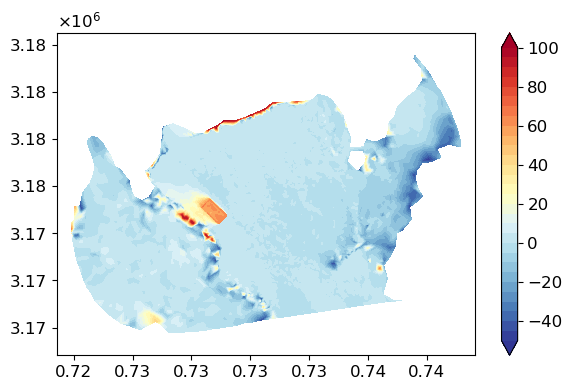

In [4]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
from matplotlib.ticker import FormatStrFormatter, FuncFormatter

# =========================
# File paths
# =========================
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_v2.sw - Result Files\west_side_barrier_reef_1.5m_v2.dfsu"

dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

item_name = "Wave power, p"
target_time = np.datetime64("2017-08-26T02:30:00")

threshold = 20.0   # percent reduction threshold

# =========================
# Open and read files
# =========================
dfs_reef = mikeio.open(dfsu_reef)
dfs_no_reef = mikeio.open(dfsu_no_reef)

ds_reef = dfs_reef.read(items=[item_name])
ds_no_reef = dfs_no_reef.read(items=[item_name])

p_reef_all = ds_reef[item_name]
p_no_reef_all = ds_no_reef[item_name]

# =========================
# Use reef mesh as reference grid
# =========================
geom_reef = p_reef_all.geometry
xy_reef = geom_reef.element_coordinates[:, :2]

# Interpolate no-reef result onto reef mesh
elem_ids, weights = p_no_reef_all.geometry.get_2d_interpolant(
    xy_reef,
    n_nearest=3,
    extrapolate=False
)

def interp_no_reef_to_reef_mesh(da_no_reef_t):
    return da_no_reef_t.geometry.interp2d(
        da_no_reef_t,
        elem_ids,
        weights
    ).flatten()

# =========================
# Calculate ΔP on reef mesh
# =========================
time_index = np.argmin(np.abs(ds_reef.time.values - target_time))
selected_time = ds_reef.time.values[time_index]

p_rf = p_reef_all.isel(time=time_index).to_numpy().flatten()
p_no_interp = interp_no_reef_to_reef_mesh(
    p_no_reef_all.isel(time=time_index)
)

# Avoid division by zero
p_no_safe = np.where(p_no_interp > 1e-6, p_no_interp, np.nan)

# ΔP = (P_no_reef - P_reef) / P_no_reef * 100
delta_p = ((p_no_safe - p_rf) / p_no_safe) * 100

print("Selected timestep:", selected_time)
print("Mean ΔP (%):", np.nanmean(delta_p))
print("Max ΔP (%):", np.nanmax(delta_p))
print("Min ΔP (%):", np.nanmin(delta_p))

# =========================
# Area where ΔP > 20% using reef mesh element area
# =========================
element_area = geom_reef.get_element_area()

mask_gt20 = np.isfinite(delta_p) & (delta_p > threshold)

area_gt20_m2 = np.nansum(element_area[mask_gt20])
area_gt20_km2 = area_gt20_m2 / 1e6

total_valid_area_m2 = np.nansum(element_area[np.isfinite(delta_p)])
total_valid_area_km2 = total_valid_area_m2 / 1e6

percent_domain_gt20 = (area_gt20_m2 / total_valid_area_m2) * 100

print("\nArea with ΔP > 20% using reef mesh area:")
print(f"  {area_gt20_m2:,.2f} m²")
print(f"  {area_gt20_km2:,.4f} km²")
print(f"  {percent_domain_gt20:.2f}% of valid reef-mesh domain")

# =========================
# Smooth spatial footprint plot on reef mesh
# =========================
x = xy_reef[:, 0]
y = xy_reef[:, 1]
z = delta_p.copy()

valid = np.isfinite(z)
valid &= (z >= -50) & (z <= 100)

x_valid = x[valid]
y_valid = y[valid]
z_valid = z[valid]

triang = tri.Triangulation(x_valid, y_valid)

# Mask large triangles to avoid interpolation over land/gaps
triangles = triang.triangles

xtri = x_valid[triangles]
ytri = y_valid[triangles]

edge1 = np.sqrt((xtri[:, 0] - xtri[:, 1])**2 + (ytri[:, 0] - ytri[:, 1])**2)
edge2 = np.sqrt((xtri[:, 1] - xtri[:, 2])**2 + (ytri[:, 1] - ytri[:, 2])**2)
edge3 = np.sqrt((xtri[:, 2] - xtri[:, 0])**2 + (ytri[:, 2] - ytri[:, 0])**2)

max_edge = np.maximum.reduce([edge1, edge2, edge3])
triang.set_mask(max_edge > 600)

# =========================
# Plot
# =========================
tick_size = 12

plt.figure(figsize=(6, 4))

levels = np.linspace(-50, 100, 31)

cf = plt.tricontourf(
    triang,
    z_valid,
    levels=levels,
    cmap="RdYlBu_r",
    extend="both"
)

cbar = plt.colorbar(cf)
cbar.ax.tick_params(labelsize=tick_size)
cbar.ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
cbar.update_ticks()

ax = plt.gca()
ax.tick_params(axis="both", labelsize=tick_size)

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1e6:.2f}"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{y/1e6:.2f}"))

ax.text(
    0.0, 1.01,
    r"$\times10^{6}$",
    transform=ax.transAxes,
    fontsize=tick_size,
    ha="left",
    va="bottom"
)

plt.axis("equal")
plt.tight_layout()
plt.show()

Selected timestep: 2017-08-26T02:30:00.000000000
Mean ΔP (%): 37.01997109880947
Max ΔP (%): 98.57051820276764
Min ΔP (%): -927.4283962777859

Area with ΔP > 20% using reef mesh area:
  1,784,273.82 m²
  1.7843 km²
  1.52% of valid reef-mesh domain


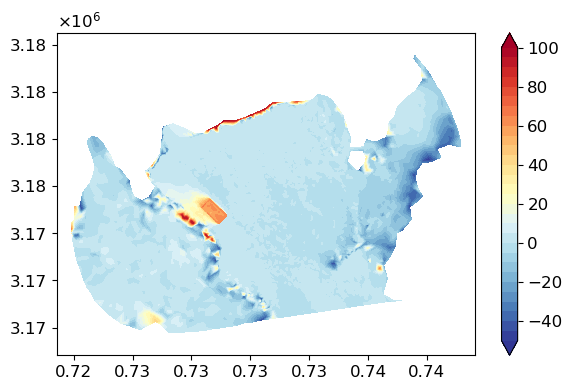

In [9]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
from matplotlib.ticker import FormatStrFormatter, FuncFormatter

# =========================
# File paths
# =========================
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_v2.sw - Result Files\west_side_barrier_reef_1.5m_v2.dfsu"

dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

item_name = "Wave power, p"
target_time = np.datetime64("2017-08-26T02:30:00")

threshold = 30.0   # percent reduction threshold

# =========================
# Open and read files
# =========================
dfs_reef = mikeio.open(dfsu_reef)
dfs_no_reef = mikeio.open(dfsu_no_reef)

ds_reef = dfs_reef.read(items=[item_name])
ds_no_reef = dfs_no_reef.read(items=[item_name])

p_reef_all = ds_reef[item_name]
p_no_reef_all = ds_no_reef[item_name]

# =========================
# Use reef mesh as reference grid
# =========================
geom_reef = p_reef_all.geometry
xy_reef = geom_reef.element_coordinates[:, :2]

# Interpolate no-reef result onto reef mesh
elem_ids, weights = p_no_reef_all.geometry.get_2d_interpolant(
    xy_reef,
    n_nearest=3,
    extrapolate=False
)

def interp_no_reef_to_reef_mesh(da_no_reef_t):
    return da_no_reef_t.geometry.interp2d(
        da_no_reef_t,
        elem_ids,
        weights
    ).flatten()

# =========================
# Calculate ΔP on reef mesh
# =========================
time_index = np.argmin(np.abs(ds_reef.time.values - target_time))
selected_time = ds_reef.time.values[time_index]

p_rf = p_reef_all.isel(time=time_index).to_numpy().flatten()
p_no_interp = interp_no_reef_to_reef_mesh(
    p_no_reef_all.isel(time=time_index)
)

# Avoid division by zero
p_no_safe = np.where(p_no_interp > 1e-6, p_no_interp, np.nan)

# ΔP = (P_no_reef - P_reef) / P_no_reef * 100
delta_p = ((p_no_safe - p_rf) / p_no_safe) * 100

print("Selected timestep:", selected_time)
print("Mean ΔP (%):", np.nanmean(delta_p))
print("Max ΔP (%):", np.nanmax(delta_p))
print("Min ΔP (%):", np.nanmin(delta_p))

# =========================
# Area where ΔP > 20% using reef mesh element area
# =========================
element_area = geom_reef.get_element_area()

mask_gt20 = np.isfinite(delta_p) & (delta_p > threshold)

area_gt20_m2 = np.nansum(element_area[mask_gt20])
area_gt20_km2 = area_gt20_m2 / 1e6

total_valid_area_m2 = np.nansum(element_area[np.isfinite(delta_p)])
total_valid_area_km2 = total_valid_area_m2 / 1e6

percent_domain_gt20 = (area_gt20_m2 / total_valid_area_m2) * 100

print("\nArea with ΔP > 20% using reef mesh area:")
print(f"  {area_gt20_m2:,.2f} m²")
print(f"  {area_gt20_km2:,.4f} km²")
print(f"  {percent_domain_gt20:.2f}% of valid reef-mesh domain")

# =========================
# Smooth spatial footprint plot on reef mesh
# =========================
x = xy_reef[:, 0]
y = xy_reef[:, 1]
z = delta_p.copy()

valid = np.isfinite(z)
valid &= (z >= -50) & (z <= 100)

x_valid = x[valid]
y_valid = y[valid]
z_valid = z[valid]

triang = tri.Triangulation(x_valid, y_valid)

# Mask large triangles to avoid interpolation over land/gaps
triangles = triang.triangles

xtri = x_valid[triangles]
ytri = y_valid[triangles]

edge1 = np.sqrt((xtri[:, 0] - xtri[:, 1])**2 + (ytri[:, 0] - ytri[:, 1])**2)
edge2 = np.sqrt((xtri[:, 1] - xtri[:, 2])**2 + (ytri[:, 1] - ytri[:, 2])**2)
edge3 = np.sqrt((xtri[:, 2] - xtri[:, 0])**2 + (ytri[:, 2] - ytri[:, 0])**2)

max_edge = np.maximum.reduce([edge1, edge2, edge3])
triang.set_mask(max_edge > 600)

# =========================
# Plot
# =========================
tick_size = 12

plt.figure(figsize=(6, 4))

levels = np.linspace(-50, 100, 31)

cf = plt.tricontourf(
    triang,
    z_valid,
    levels=levels,
    cmap="RdYlBu_r",
    extend="both"
)

cbar = plt.colorbar(cf)
cbar.ax.tick_params(labelsize=tick_size)
cbar.ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
cbar.update_ticks()

ax = plt.gca()
ax.tick_params(axis="both", labelsize=tick_size)

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1e6:.2f}"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{y/1e6:.2f}"))

ax.text(
    0.0, 1.01,
    r"$\times10^{6}$",
    transform=ax.transAxes,
    fontsize=tick_size,
    ha="left",
    va="bottom"
)

plt.axis("equal")
plt.tight_layout()
plt.show()

Selected timestep: 2017-08-26T02:30:00.000000000
Mean ΔP (%): 37.01997109880947
Max ΔP (%): 98.57051820276764
Min ΔP (%): -927.4283962777859

Area with ΔP > 10% using reef mesh area:
  4,673,668.80 m²
  4.6737 km²
  3.98% of valid reef-mesh domain


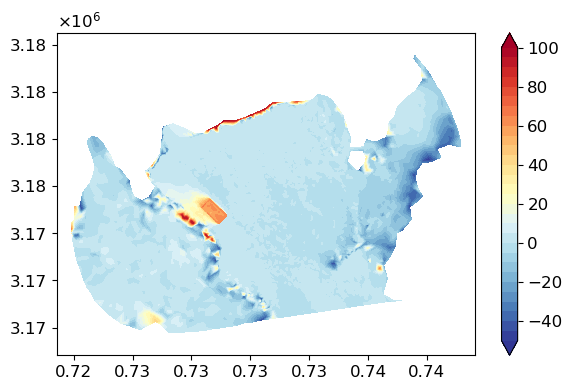

In [11]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
from matplotlib.ticker import FormatStrFormatter, FuncFormatter

# =========================
# File paths
# =========================
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_v2.sw - Result Files\west_side_barrier_reef_1.5m_v2.dfsu"

dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

item_name = "Wave power, p"
target_time = np.datetime64("2017-08-26T02:30:00")

threshold = 10.0   # percent reduction threshold

# =========================
# Open and read files
# =========================
dfs_reef = mikeio.open(dfsu_reef)
dfs_no_reef = mikeio.open(dfsu_no_reef)

ds_reef = dfs_reef.read(items=[item_name])
ds_no_reef = dfs_no_reef.read(items=[item_name])

p_reef_all = ds_reef[item_name]
p_no_reef_all = ds_no_reef[item_name]

# =========================
# Use reef mesh as reference grid
# =========================
geom_reef = p_reef_all.geometry
xy_reef = geom_reef.element_coordinates[:, :2]

# Interpolate no-reef result onto reef mesh
elem_ids, weights = p_no_reef_all.geometry.get_2d_interpolant(
    xy_reef,
    n_nearest=3,
    extrapolate=False
)

def interp_no_reef_to_reef_mesh(da_no_reef_t):
    return da_no_reef_t.geometry.interp2d(
        da_no_reef_t,
        elem_ids,
        weights
    ).flatten()

# =========================
# Calculate ΔP on reef mesh
# =========================
time_index = np.argmin(np.abs(ds_reef.time.values - target_time))
selected_time = ds_reef.time.values[time_index]

p_rf = p_reef_all.isel(time=time_index).to_numpy().flatten()
p_no_interp = interp_no_reef_to_reef_mesh(
    p_no_reef_all.isel(time=time_index)
)

# Avoid division by zero
p_no_safe = np.where(p_no_interp > 1e-6, p_no_interp, np.nan)

# ΔP = (P_no_reef - P_reef) / P_no_reef * 100
delta_p = ((p_no_safe - p_rf) / p_no_safe) * 100

print("Selected timestep:", selected_time)
print("Mean ΔP (%):", np.nanmean(delta_p))
print("Max ΔP (%):", np.nanmax(delta_p))
print("Min ΔP (%):", np.nanmin(delta_p))

# =========================
# Area where ΔP > 20% using reef mesh element area
# =========================
element_area = geom_reef.get_element_area()

mask_gt20 = np.isfinite(delta_p) & (delta_p > threshold)

area_gt20_m2 = np.nansum(element_area[mask_gt20])
area_gt20_km2 = area_gt20_m2 / 1e6

total_valid_area_m2 = np.nansum(element_area[np.isfinite(delta_p)])
total_valid_area_km2 = total_valid_area_m2 / 1e6

percent_domain_gt20 = (area_gt20_m2 / total_valid_area_m2) * 100

print("\nArea with ΔP > 10% using reef mesh area:")
print(f"  {area_gt20_m2:,.2f} m²")
print(f"  {area_gt20_km2:,.4f} km²")
print(f"  {percent_domain_gt20:.2f}% of valid reef-mesh domain")

# =========================
# Smooth spatial footprint plot on reef mesh
# =========================
x = xy_reef[:, 0]
y = xy_reef[:, 1]
z = delta_p.copy()

valid = np.isfinite(z)
valid &= (z >= -50) & (z <= 100)

x_valid = x[valid]
y_valid = y[valid]
z_valid = z[valid]

triang = tri.Triangulation(x_valid, y_valid)

# Mask large triangles to avoid interpolation over land/gaps
triangles = triang.triangles

xtri = x_valid[triangles]
ytri = y_valid[triangles]

edge1 = np.sqrt((xtri[:, 0] - xtri[:, 1])**2 + (ytri[:, 0] - ytri[:, 1])**2)
edge2 = np.sqrt((xtri[:, 1] - xtri[:, 2])**2 + (ytri[:, 1] - ytri[:, 2])**2)
edge3 = np.sqrt((xtri[:, 2] - xtri[:, 0])**2 + (ytri[:, 2] - ytri[:, 0])**2)

max_edge = np.maximum.reduce([edge1, edge2, edge3])
triang.set_mask(max_edge > 600)

# =========================
# Plot
# =========================
tick_size = 12

plt.figure(figsize=(6, 4))

levels = np.linspace(-50, 100, 31)

cf = plt.tricontourf(
    triang,
    z_valid,
    levels=levels,
    cmap="RdYlBu_r",
    extend="both"
)

cbar = plt.colorbar(cf)
cbar.ax.tick_params(labelsize=tick_size)
cbar.ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
cbar.update_ticks()

ax = plt.gca()
ax.tick_params(axis="both", labelsize=tick_size)

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1e6:.2f}"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{y/1e6:.2f}"))

ax.text(
    0.0, 1.01,
    r"$\times10^{6}$",
    transform=ax.transAxes,
    fontsize=tick_size,
    ha="left",
    va="bottom"
)

plt.axis("equal")
plt.tight_layout()
plt.show()


Selected timestep: 2017-08-26T02:30:00.000000000
Mean ΔP (%): -1.4147538514639333
Max ΔP (%): 87.15285591014181
Min ΔP (%): -2265.6026675119538
Area with ΔP > 20%:
  4,593,131.72 m²
  4.5931 km²
  3.93% of valid model area


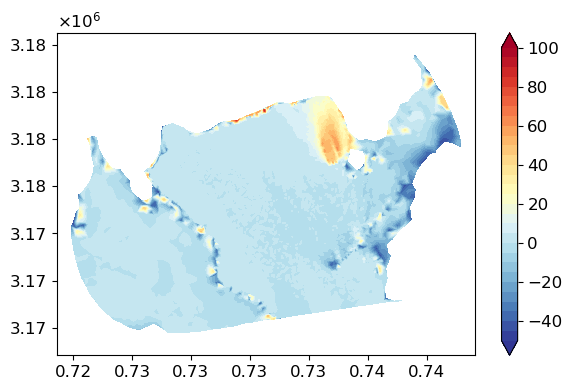

In [2]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
from matplotlib.ticker import FormatStrFormatter, FuncFormatter

# =========================
# File paths
# =========================
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\east_side_barrier_reef_1.5m_v2.sw - Result Files\east_side_reef_1.5m_v2.dfsu"
dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

item_name = "Wave power, p"
target_time = np.datetime64("2017-08-26T02:30:00")

# =========================
# Open and read files
# =========================
dfs_reef = mikeio.open(dfsu_reef)
dfs_no_reef = mikeio.open(dfsu_no_reef)

ds_reef = dfs_reef.read(items=[item_name])
ds_no_reef = dfs_no_reef.read(items=[item_name])

p_reef_all = ds_reef[item_name]
p_no_reef_all = ds_no_reef[item_name]

geom_ref = p_no_reef_all.geometry
xy_ref = geom_ref.element_coordinates[:, :2]

elem_ids, weights = p_reef_all.geometry.get_2d_interpolant(
    xy_ref,
    n_nearest=3,
    extrapolate=False
)

def interp_reef_to_ref(da_reef_t):
    return da_reef_t.geometry.interp2d(
        da_reef_t,
        elem_ids,
        weights
    ).flatten()

# =========================
# Calculate ΔP
# =========================
time_index = np.argmin(np.abs(ds_no_reef.time.values - target_time))
selected_time = ds_no_reef.time.values[time_index]

p_no = p_no_reef_all.isel(time=time_index).to_numpy().flatten()
p_rf = interp_reef_to_ref(p_reef_all.isel(time=time_index))

p_no_safe = np.where(p_no > 1e-6, p_no, np.nan)

delta_p = ((p_no_safe - p_rf) / p_no_safe) * 100

print("Selected timestep:", selected_time)
print("Mean ΔP (%):", np.nanmean(delta_p))
print("Max ΔP (%):", np.nanmax(delta_p))
print("Min ΔP (%):", np.nanmin(delta_p))

# =========================
# Area where ΔP > 20%
# =========================
threshold = 20.0

# Element area from reference/no-reef mesh
element_area = geom_ref.get_element_area()

mask_gt20 = np.isfinite(delta_p) & (delta_p > threshold)

area_gt20_m2 = np.nansum(element_area[mask_gt20])
area_gt20_km2 = area_gt20_m2 / 1e6

total_valid_area_m2 = np.nansum(element_area[np.isfinite(delta_p)])
total_valid_area_km2 = total_valid_area_m2 / 1e6

percent_domain_gt20 = (area_gt20_m2 / total_valid_area_m2) * 100

print("Area with ΔP > 20%:")
print(f"  {area_gt20_m2:,.2f} m²")
print(f"  {area_gt20_km2:,.4f} km²")
print(f"  {percent_domain_gt20:.2f}% of valid model area")

# =========================
# Smooth spatial footprint plot
# =========================
x = xy_ref[:, 0]
y = xy_ref[:, 1]
z = delta_p.copy()

valid = np.isfinite(z)
valid &= (z >= -50) & (z <= 100)

x_valid = x[valid]
y_valid = y[valid]
z_valid = z[valid]

triang = tri.Triangulation(x_valid, y_valid)

triangles = triang.triangles
xtri = x_valid[triangles]
ytri = y_valid[triangles]

edge1 = np.sqrt((xtri[:, 0] - xtri[:, 1])**2 + (ytri[:, 0] - ytri[:, 1])**2)
edge2 = np.sqrt((xtri[:, 1] - xtri[:, 2])**2 + (ytri[:, 1] - ytri[:, 2])**2)
edge3 = np.sqrt((xtri[:, 2] - xtri[:, 0])**2 + (ytri[:, 2] - ytri[:, 0])**2)

max_edge = np.maximum.reduce([edge1, edge2, edge3])
triang.set_mask(max_edge > 600)

# =========================
# Plot
# =========================
tick_size = 12

plt.figure(figsize=(6, 4))

levels = np.linspace(-50, 100, 31)

cf = plt.tricontourf(
    triang,
    z_valid,
    levels=levels,
    cmap="RdYlBu_r",
    extend="both"
)

cbar = plt.colorbar(cf)
cbar.ax.tick_params(labelsize=tick_size)
cbar.ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
cbar.update_ticks()

ax = plt.gca()
ax.tick_params(axis="both", labelsize=tick_size)

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1e6:.2f}"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{y/1e6:.2f}"))

ax.text(
    0.0, 1.01,
    r"$\times10^{6}$",
    transform=ax.transAxes,
    fontsize=tick_size,
    ha="left",
    va="bottom"
)

plt.axis("equal")
plt.tight_layout()
plt.show()


Selected timestep: 2017-08-26T02:30:00.000000000
Mean ΔP (%): 29.759591856341864
Max ΔP (%): 99.93995367331186
Min ΔP (%): -252.3395307683627

Area with ΔP > 20% using reef mesh area:
  4,738,442.83 m²
  4.7384 km²
  4.04% of valid reef-mesh domain


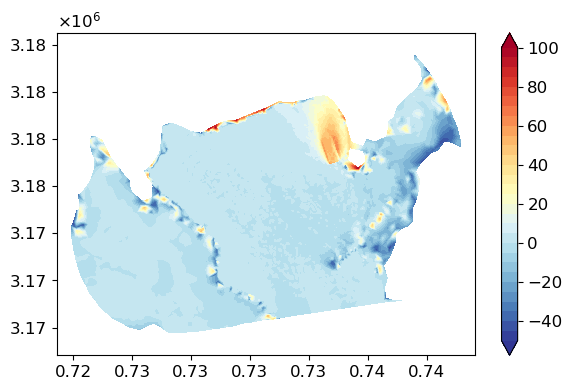

In [6]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
from matplotlib.ticker import FormatStrFormatter, FuncFormatter

# =========================
# File paths
# =========================
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\east_side_barrier_reef_1.5m_v2.sw - Result Files\east_side_reef_1.5m_v2.dfsu"

dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

item_name = "Wave power, p"
target_time = np.datetime64("2017-08-26T02:30:00")

threshold = 20.0   # percent reduction threshold

# =========================
# Open and read files
# =========================
dfs_reef = mikeio.open(dfsu_reef)
dfs_no_reef = mikeio.open(dfsu_no_reef)

ds_reef = dfs_reef.read(items=[item_name])
ds_no_reef = dfs_no_reef.read(items=[item_name])

p_reef_all = ds_reef[item_name]
p_no_reef_all = ds_no_reef[item_name]

# =========================
# Use reef mesh as reference grid
# =========================
geom_reef = p_reef_all.geometry
xy_reef = geom_reef.element_coordinates[:, :2]

# Interpolate no-reef result onto reef mesh
elem_ids, weights = p_no_reef_all.geometry.get_2d_interpolant(
    xy_reef,
    n_nearest=3,
    extrapolate=False
)

def interp_no_reef_to_reef_mesh(da_no_reef_t):
    return da_no_reef_t.geometry.interp2d(
        da_no_reef_t,
        elem_ids,
        weights
    ).flatten()

# =========================
# Calculate ΔP on reef mesh
# =========================
time_index = np.argmin(np.abs(ds_reef.time.values - target_time))
selected_time = ds_reef.time.values[time_index]

p_rf = p_reef_all.isel(time=time_index).to_numpy().flatten()
p_no_interp = interp_no_reef_to_reef_mesh(
    p_no_reef_all.isel(time=time_index)
)

# Avoid division by zero
p_no_safe = np.where(p_no_interp > 1e-6, p_no_interp, np.nan)

# ΔP = (P_no_reef - P_reef) / P_no_reef * 100
delta_p = ((p_no_safe - p_rf) / p_no_safe) * 100

print("Selected timestep:", selected_time)
print("Mean ΔP (%):", np.nanmean(delta_p))
print("Max ΔP (%):", np.nanmax(delta_p))
print("Min ΔP (%):", np.nanmin(delta_p))

# =========================
# Area where ΔP > 20% using reef mesh element area
# =========================
element_area = geom_reef.get_element_area()

mask_gt20 = np.isfinite(delta_p) & (delta_p > threshold)

area_gt20_m2 = np.nansum(element_area[mask_gt20])
area_gt20_km2 = area_gt20_m2 / 1e6

total_valid_area_m2 = np.nansum(element_area[np.isfinite(delta_p)])
total_valid_area_km2 = total_valid_area_m2 / 1e6

percent_domain_gt20 = (area_gt20_m2 / total_valid_area_m2) * 100

print("\nArea with ΔP > 20% using reef mesh area:")
print(f"  {area_gt20_m2:,.2f} m²")
print(f"  {area_gt20_km2:,.4f} km²")
print(f"  {percent_domain_gt20:.2f}% of valid reef-mesh domain")

# =========================
# Smooth spatial footprint plot on reef mesh
# =========================
x = xy_reef[:, 0]
y = xy_reef[:, 1]
z = delta_p.copy()

valid = np.isfinite(z)
valid &= (z >= -50) & (z <= 100)

x_valid = x[valid]
y_valid = y[valid]
z_valid = z[valid]

triang = tri.Triangulation(x_valid, y_valid)

# Mask large triangles to avoid interpolation over land/gaps
triangles = triang.triangles

xtri = x_valid[triangles]
ytri = y_valid[triangles]

edge1 = np.sqrt((xtri[:, 0] - xtri[:, 1])**2 + (ytri[:, 0] - ytri[:, 1])**2)
edge2 = np.sqrt((xtri[:, 1] - xtri[:, 2])**2 + (ytri[:, 1] - ytri[:, 2])**2)
edge3 = np.sqrt((xtri[:, 2] - xtri[:, 0])**2 + (ytri[:, 2] - ytri[:, 0])**2)

max_edge = np.maximum.reduce([edge1, edge2, edge3])
triang.set_mask(max_edge > 600)

# =========================
# Plot
# =========================
tick_size = 12

plt.figure(figsize=(6, 4))

levels = np.linspace(-50, 100, 31)

cf = plt.tricontourf(
    triang,
    z_valid,
    levels=levels,
    cmap="RdYlBu_r",
    extend="both"
)

cbar = plt.colorbar(cf)
cbar.ax.tick_params(labelsize=tick_size)
cbar.ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
cbar.update_ticks()

ax = plt.gca()
ax.tick_params(axis="both", labelsize=tick_size)

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1e6:.2f}"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{y/1e6:.2f}"))

ax.text(
    0.0, 1.01,
    r"$\times10^{6}$",
    transform=ax.transAxes,
    fontsize=tick_size,
    ha="left",
    va="bottom"
)

plt.axis("equal")
plt.tight_layout()
plt.show()

Selected timestep: 2017-08-26T02:30:00.000000000
Mean ΔP (%): 29.759591856341864
Max ΔP (%): 99.93995367331186
Min ΔP (%): -252.3395307683627

Area with ΔP > 20% using reef mesh area:
  2,959,250.80 m²
  2.9593 km²
  2.53% of valid reef-mesh domain


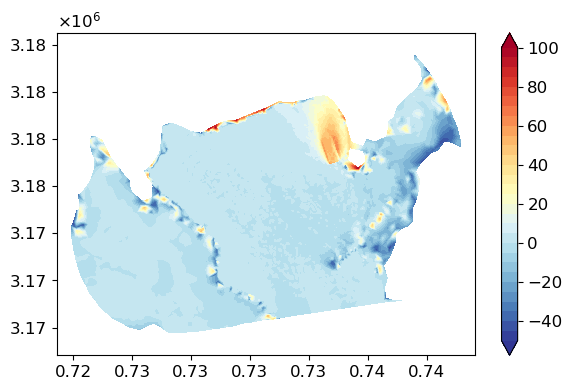

In [7]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
from matplotlib.ticker import FormatStrFormatter, FuncFormatter

# =========================
# File paths
# =========================
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\east_side_barrier_reef_1.5m_v2.sw - Result Files\east_side_reef_1.5m_v2.dfsu"

dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

item_name = "Wave power, p"
target_time = np.datetime64("2017-08-26T02:30:00")

threshold = 30.0   # percent reduction threshold

# =========================
# Open and read files
# =========================
dfs_reef = mikeio.open(dfsu_reef)
dfs_no_reef = mikeio.open(dfsu_no_reef)

ds_reef = dfs_reef.read(items=[item_name])
ds_no_reef = dfs_no_reef.read(items=[item_name])

p_reef_all = ds_reef[item_name]
p_no_reef_all = ds_no_reef[item_name]

# =========================
# Use reef mesh as reference grid
# =========================
geom_reef = p_reef_all.geometry
xy_reef = geom_reef.element_coordinates[:, :2]

# Interpolate no-reef result onto reef mesh
elem_ids, weights = p_no_reef_all.geometry.get_2d_interpolant(
    xy_reef,
    n_nearest=3,
    extrapolate=False
)

def interp_no_reef_to_reef_mesh(da_no_reef_t):
    return da_no_reef_t.geometry.interp2d(
        da_no_reef_t,
        elem_ids,
        weights
    ).flatten()

# =========================
# Calculate ΔP on reef mesh
# =========================
time_index = np.argmin(np.abs(ds_reef.time.values - target_time))
selected_time = ds_reef.time.values[time_index]

p_rf = p_reef_all.isel(time=time_index).to_numpy().flatten()
p_no_interp = interp_no_reef_to_reef_mesh(
    p_no_reef_all.isel(time=time_index)
)

# Avoid division by zero
p_no_safe = np.where(p_no_interp > 1e-6, p_no_interp, np.nan)

# ΔP = (P_no_reef - P_reef) / P_no_reef * 100
delta_p = ((p_no_safe - p_rf) / p_no_safe) * 100

print("Selected timestep:", selected_time)
print("Mean ΔP (%):", np.nanmean(delta_p))
print("Max ΔP (%):", np.nanmax(delta_p))
print("Min ΔP (%):", np.nanmin(delta_p))

# =========================
# Area where ΔP > 20% using reef mesh element area
# =========================
element_area = geom_reef.get_element_area()

mask_gt20 = np.isfinite(delta_p) & (delta_p > threshold)

area_gt20_m2 = np.nansum(element_area[mask_gt20])
area_gt20_km2 = area_gt20_m2 / 1e6

total_valid_area_m2 = np.nansum(element_area[np.isfinite(delta_p)])
total_valid_area_km2 = total_valid_area_m2 / 1e6

percent_domain_gt20 = (area_gt20_m2 / total_valid_area_m2) * 100

print("\nArea with ΔP > 20% using reef mesh area:")
print(f"  {area_gt20_m2:,.2f} m²")
print(f"  {area_gt20_km2:,.4f} km²")
print(f"  {percent_domain_gt20:.2f}% of valid reef-mesh domain")

# =========================
# Smooth spatial footprint plot on reef mesh
# =========================
x = xy_reef[:, 0]
y = xy_reef[:, 1]
z = delta_p.copy()

valid = np.isfinite(z)
valid &= (z >= -50) & (z <= 100)

x_valid = x[valid]
y_valid = y[valid]
z_valid = z[valid]

triang = tri.Triangulation(x_valid, y_valid)

# Mask large triangles to avoid interpolation over land/gaps
triangles = triang.triangles

xtri = x_valid[triangles]
ytri = y_valid[triangles]

edge1 = np.sqrt((xtri[:, 0] - xtri[:, 1])**2 + (ytri[:, 0] - ytri[:, 1])**2)
edge2 = np.sqrt((xtri[:, 1] - xtri[:, 2])**2 + (ytri[:, 1] - ytri[:, 2])**2)
edge3 = np.sqrt((xtri[:, 2] - xtri[:, 0])**2 + (ytri[:, 2] - ytri[:, 0])**2)

max_edge = np.maximum.reduce([edge1, edge2, edge3])
triang.set_mask(max_edge > 600)

# =========================
# Plot
# =========================
tick_size = 12

plt.figure(figsize=(6, 4))

levels = np.linspace(-50, 100, 31)

cf = plt.tricontourf(
    triang,
    z_valid,
    levels=levels,
    cmap="RdYlBu_r",
    extend="both"
)

cbar = plt.colorbar(cf)
cbar.ax.tick_params(labelsize=tick_size)
cbar.ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
cbar.update_ticks()

ax = plt.gca()
ax.tick_params(axis="both", labelsize=tick_size)

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1e6:.2f}"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{y/1e6:.2f}"))

ax.text(
    0.0, 1.01,
    r"$\times10^{6}$",
    transform=ax.transAxes,
    fontsize=tick_size,
    ha="left",
    va="bottom"
)

plt.axis("equal")
plt.tight_layout()
plt.show()

Selected timestep: 2017-08-26T02:30:00.000000000
Mean ΔP (%): 29.759591856341864
Max ΔP (%): 99.93995367331186
Min ΔP (%): -252.3395307683627

Area with ΔP > 10% using reef mesh area:
  7,069,608.10 m²
  7.0696 km²
  6.03% of valid reef-mesh domain


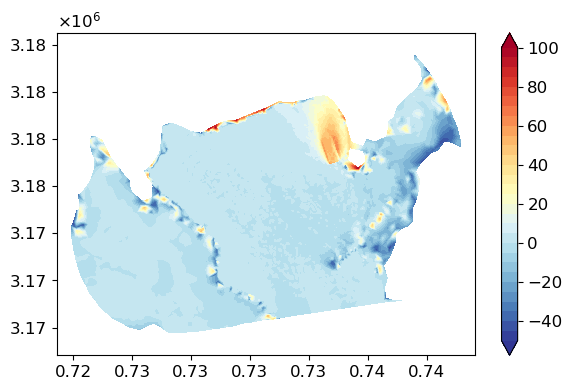

In [12]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
from matplotlib.ticker import FormatStrFormatter, FuncFormatter

# =========================
# File paths
# =========================
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\east_side_barrier_reef_1.5m_v2.sw - Result Files\east_side_reef_1.5m_v2.dfsu"

dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

item_name = "Wave power, p"
target_time = np.datetime64("2017-08-26T02:30:00")

threshold = 10.0   # percent reduction threshold

# =========================
# Open and read files
# =========================
dfs_reef = mikeio.open(dfsu_reef)
dfs_no_reef = mikeio.open(dfsu_no_reef)

ds_reef = dfs_reef.read(items=[item_name])
ds_no_reef = dfs_no_reef.read(items=[item_name])

p_reef_all = ds_reef[item_name]
p_no_reef_all = ds_no_reef[item_name]

# =========================
# Use reef mesh as reference grid
# =========================
geom_reef = p_reef_all.geometry
xy_reef = geom_reef.element_coordinates[:, :2]

# Interpolate no-reef result onto reef mesh
elem_ids, weights = p_no_reef_all.geometry.get_2d_interpolant(
    xy_reef,
    n_nearest=3,
    extrapolate=False
)

def interp_no_reef_to_reef_mesh(da_no_reef_t):
    return da_no_reef_t.geometry.interp2d(
        da_no_reef_t,
        elem_ids,
        weights
    ).flatten()

# =========================
# Calculate ΔP on reef mesh
# =========================
time_index = np.argmin(np.abs(ds_reef.time.values - target_time))
selected_time = ds_reef.time.values[time_index]

p_rf = p_reef_all.isel(time=time_index).to_numpy().flatten()
p_no_interp = interp_no_reef_to_reef_mesh(
    p_no_reef_all.isel(time=time_index)
)

# Avoid division by zero
p_no_safe = np.where(p_no_interp > 1e-6, p_no_interp, np.nan)

# ΔP = (P_no_reef - P_reef) / P_no_reef * 100
delta_p = ((p_no_safe - p_rf) / p_no_safe) * 100

print("Selected timestep:", selected_time)
print("Mean ΔP (%):", np.nanmean(delta_p))
print("Max ΔP (%):", np.nanmax(delta_p))
print("Min ΔP (%):", np.nanmin(delta_p))

# =========================
# Area where ΔP > 20% using reef mesh element area
# =========================
element_area = geom_reef.get_element_area()

mask_gt20 = np.isfinite(delta_p) & (delta_p > threshold)

area_gt20_m2 = np.nansum(element_area[mask_gt20])
area_gt20_km2 = area_gt20_m2 / 1e6

total_valid_area_m2 = np.nansum(element_area[np.isfinite(delta_p)])
total_valid_area_km2 = total_valid_area_m2 / 1e6

percent_domain_gt20 = (area_gt20_m2 / total_valid_area_m2) * 100

print("\nArea with ΔP > 10% using reef mesh area:")
print(f"  {area_gt20_m2:,.2f} m²")
print(f"  {area_gt20_km2:,.4f} km²")
print(f"  {percent_domain_gt20:.2f}% of valid reef-mesh domain")

# =========================
# Smooth spatial footprint plot on reef mesh
# =========================
x = xy_reef[:, 0]
y = xy_reef[:, 1]
z = delta_p.copy()

valid = np.isfinite(z)
valid &= (z >= -50) & (z <= 100)

x_valid = x[valid]
y_valid = y[valid]
z_valid = z[valid]

triang = tri.Triangulation(x_valid, y_valid)

# Mask large triangles to avoid interpolation over land/gaps
triangles = triang.triangles

xtri = x_valid[triangles]
ytri = y_valid[triangles]

edge1 = np.sqrt((xtri[:, 0] - xtri[:, 1])**2 + (ytri[:, 0] - ytri[:, 1])**2)
edge2 = np.sqrt((xtri[:, 1] - xtri[:, 2])**2 + (ytri[:, 1] - ytri[:, 2])**2)
edge3 = np.sqrt((xtri[:, 2] - xtri[:, 0])**2 + (ytri[:, 2] - ytri[:, 0])**2)

max_edge = np.maximum.reduce([edge1, edge2, edge3])
triang.set_mask(max_edge > 600)

# =========================
# Plot
# =========================
tick_size = 12

plt.figure(figsize=(6, 4))

levels = np.linspace(-50, 100, 31)

cf = plt.tricontourf(
    triang,
    z_valid,
    levels=levels,
    cmap="RdYlBu_r",
    extend="both"
)

cbar = plt.colorbar(cf)
cbar.ax.tick_params(labelsize=tick_size)
cbar.ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
cbar.update_ticks()

ax = plt.gca()
ax.tick_params(axis="both", labelsize=tick_size)

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1e6:.2f}"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{y/1e6:.2f}"))

ax.text(
    0.0, 1.01,
    r"$\times10^{6}$",
    transform=ax.transAxes,
    fontsize=tick_size,
    ha="left",
    va="bottom"
)

plt.axis("equal")
plt.tight_layout()
plt.show()

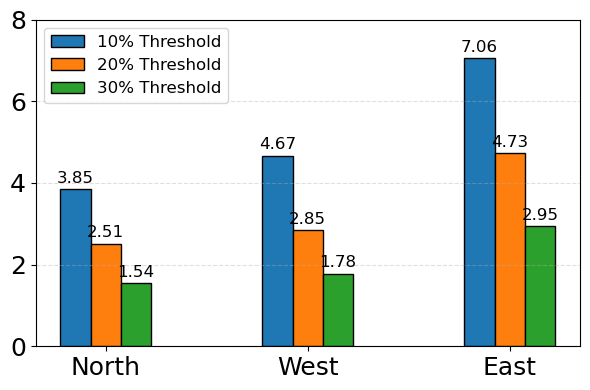

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Data
# =========================
locations = ["North", "West", "East"]

threshold_10 = [3.85, 4.67, 7.06]
threshold_20 = [2.51, 2.85, 4.73]
threshold_30 = [1.54, 1.78, 2.95]

x = np.arange(len(locations))
width = 0.15

# =========================
# Plot
# =========================
fig, ax = plt.subplots(figsize=(6,4))

bars1 = ax.bar(
    x - width,
    threshold_10,
    width,
    label="10% Threshold",
    edgecolor="black"
)

bars2 = ax.bar(
    x,
    threshold_20,
    width,
    label="20% Threshold",
    edgecolor="black"
)

bars3 = ax.bar(
    x + width,
    threshold_30,
    width,
    label="30% Threshold",
    edgecolor="black"
)

# =========================
# Formatting
# =========================
ax.set_xticks(x)
ax.set_xticklabels(locations, fontsize=18)
# Increase y-axis tick label size
ax.tick_params(axis='y', labelsize=18)
# ax.set_xlabel("Artificial Reef Location", fontsize=13)
# ax.set_ylabel(r"Wave Attenuation Footprint (km$^2$)", fontsize=13)

ax.legend(fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Add value labels
def add_labels(bars):
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            h + 0.08,
            f"{h:.2f}",
            ha='center',
            va='bottom',
            fontsize=12
        )

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)

ax.set_ylim(0, 8)

plt.tight_layout()
plt.show()

Selected timestep: 2017-08-26T02:30:00.000000000
Mean ΔP (%): 34.429510024784946
Max ΔP (%): 99.31528500084184
Min ΔP (%): -635.8952533724716

Area with ΔP > 10% using reef mesh area:
  5,809,835.61 m²
  5.8098 km²
  4.98% of valid reef-mesh domain


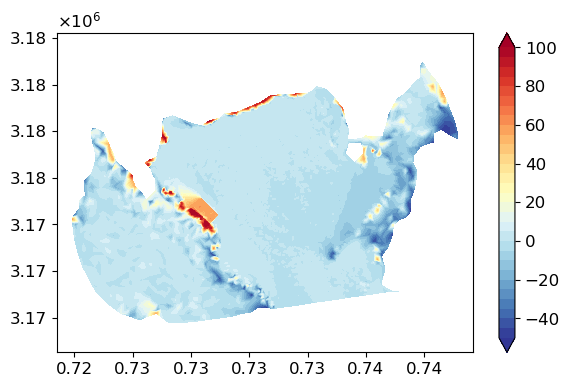

In [22]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
from matplotlib.ticker import FormatStrFormatter, FuncFormatter

# =========================
# File paths
# =========================
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_fringing_reef_v1.sw - Result Files\west_side_fringing_reef_1.5m_v2.dfsu"

dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

item_name = "Wave power, p"
target_time = np.datetime64("2017-08-26T02:30:00")

threshold = 10.0   # percent reduction threshold

# =========================
# Open and read files
# =========================
dfs_reef = mikeio.open(dfsu_reef)
dfs_no_reef = mikeio.open(dfsu_no_reef)

ds_reef = dfs_reef.read(items=[item_name])
ds_no_reef = dfs_no_reef.read(items=[item_name])

p_reef_all = ds_reef[item_name]
p_no_reef_all = ds_no_reef[item_name]

# =========================
# Use reef mesh as reference grid
# =========================
geom_reef = p_reef_all.geometry
xy_reef = geom_reef.element_coordinates[:, :2]

# Interpolate no-reef result onto reef mesh
elem_ids, weights = p_no_reef_all.geometry.get_2d_interpolant(
    xy_reef,
    n_nearest=3,
    extrapolate=False
)

def interp_no_reef_to_reef_mesh(da_no_reef_t):
    return da_no_reef_t.geometry.interp2d(
        da_no_reef_t,
        elem_ids,
        weights
    ).flatten()

# =========================
# Calculate ΔP on reef mesh
# =========================
time_index = np.argmin(np.abs(ds_reef.time.values - target_time))
selected_time = ds_reef.time.values[time_index]

p_rf = p_reef_all.isel(time=time_index).to_numpy().flatten()
p_no_interp = interp_no_reef_to_reef_mesh(
    p_no_reef_all.isel(time=time_index)
)

# Avoid division by zero
p_no_safe = np.where(p_no_interp > 1e-6, p_no_interp, np.nan)

# ΔP = (P_no_reef - P_reef) / P_no_reef * 100
delta_p = ((p_no_safe - p_rf) / p_no_safe) * 100

print("Selected timestep:", selected_time)
print("Mean ΔP (%):", np.nanmean(delta_p))
print("Max ΔP (%):", np.nanmax(delta_p))
print("Min ΔP (%):", np.nanmin(delta_p))

# =========================
# Area where ΔP > 20% using reef mesh element area
# =========================
element_area = geom_reef.get_element_area()

mask_gt20 = np.isfinite(delta_p) & (delta_p > threshold)

area_gt20_m2 = np.nansum(element_area[mask_gt20])
area_gt20_km2 = area_gt20_m2 / 1e6

total_valid_area_m2 = np.nansum(element_area[np.isfinite(delta_p)])
total_valid_area_km2 = total_valid_area_m2 / 1e6

percent_domain_gt20 = (area_gt20_m2 / total_valid_area_m2) * 100

print("\nArea with ΔP > 10% using reef mesh area:")
print(f"  {area_gt20_m2:,.2f} m²")
print(f"  {area_gt20_km2:,.4f} km²")
print(f"  {percent_domain_gt20:.2f}% of valid reef-mesh domain")

# =========================
# Smooth spatial footprint plot on reef mesh
# =========================
x = xy_reef[:, 0]
y = xy_reef[:, 1]
z = delta_p.copy()

valid = np.isfinite(z)
valid &= (z >= -50) & (z <= 100)

x_valid = x[valid]
y_valid = y[valid]
z_valid = z[valid]

triang = tri.Triangulation(x_valid, y_valid)

# Mask large triangles to avoid interpolation over land/gaps
triangles = triang.triangles

xtri = x_valid[triangles]
ytri = y_valid[triangles]

edge1 = np.sqrt((xtri[:, 0] - xtri[:, 1])**2 + (ytri[:, 0] - ytri[:, 1])**2)
edge2 = np.sqrt((xtri[:, 1] - xtri[:, 2])**2 + (ytri[:, 1] - ytri[:, 2])**2)
edge3 = np.sqrt((xtri[:, 2] - xtri[:, 0])**2 + (ytri[:, 2] - ytri[:, 0])**2)

max_edge = np.maximum.reduce([edge1, edge2, edge3])
triang.set_mask(max_edge > 600)

# =========================
# Plot
# =========================
tick_size = 12

plt.figure(figsize=(6, 4))

levels = np.linspace(-50, 100, 31)

cf = plt.tricontourf(
    triang,
    z_valid,
    levels=levels,
    cmap="RdYlBu_r",
    extend="both"
)

cbar = plt.colorbar(cf)
cbar.ax.tick_params(labelsize=tick_size)
cbar.ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
cbar.update_ticks()

ax = plt.gca()
ax.tick_params(axis="both", labelsize=tick_size)

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1e6:.2f}"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{y/1e6:.2f}"))

ax.text(
    0.0, 1.01,
    r"$\times10^{6}$",
    transform=ax.transAxes,
    fontsize=tick_size,
    ha="left",
    va="bottom"
)

plt.axis("equal")
plt.tight_layout()
plt.show()


Selected timestep: 2017-08-26T02:30:00.000000000
Mean ΔP (%): 34.429510024784946
Max ΔP (%): 99.31528500084184
Min ΔP (%): -635.8952533724716

Area with ΔP > 20% using reef mesh area:
  3,208,051.47 m²
  3.2081 km²
  2.75% of valid reef-mesh domain


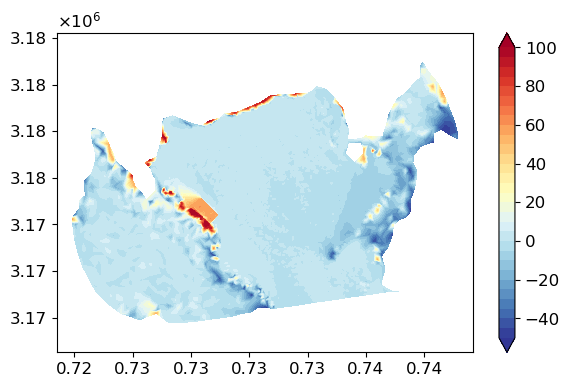

In [21]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
from matplotlib.ticker import FormatStrFormatter, FuncFormatter

# =========================
# File paths
# =========================
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_fringing_reef_v1.sw - Result Files\west_side_fringing_reef_1.5m_v2.dfsu"

dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

item_name = "Wave power, p"
target_time = np.datetime64("2017-08-26T02:30:00")

threshold = 20.0   # percent reduction threshold

# =========================
# Open and read files
# =========================
dfs_reef = mikeio.open(dfsu_reef)
dfs_no_reef = mikeio.open(dfsu_no_reef)

ds_reef = dfs_reef.read(items=[item_name])
ds_no_reef = dfs_no_reef.read(items=[item_name])

p_reef_all = ds_reef[item_name]
p_no_reef_all = ds_no_reef[item_name]

# =========================
# Use reef mesh as reference grid
# =========================
geom_reef = p_reef_all.geometry
xy_reef = geom_reef.element_coordinates[:, :2]

# Interpolate no-reef result onto reef mesh
elem_ids, weights = p_no_reef_all.geometry.get_2d_interpolant(
    xy_reef,
    n_nearest=3,
    extrapolate=False
)

def interp_no_reef_to_reef_mesh(da_no_reef_t):
    return da_no_reef_t.geometry.interp2d(
        da_no_reef_t,
        elem_ids,
        weights
    ).flatten()

# =========================
# Calculate ΔP on reef mesh
# =========================
time_index = np.argmin(np.abs(ds_reef.time.values - target_time))
selected_time = ds_reef.time.values[time_index]

p_rf = p_reef_all.isel(time=time_index).to_numpy().flatten()
p_no_interp = interp_no_reef_to_reef_mesh(
    p_no_reef_all.isel(time=time_index)
)

# Avoid division by zero
p_no_safe = np.where(p_no_interp > 1e-6, p_no_interp, np.nan)

# ΔP = (P_no_reef - P_reef) / P_no_reef * 100
delta_p = ((p_no_safe - p_rf) / p_no_safe) * 100

print("Selected timestep:", selected_time)
print("Mean ΔP (%):", np.nanmean(delta_p))
print("Max ΔP (%):", np.nanmax(delta_p))
print("Min ΔP (%):", np.nanmin(delta_p))

# =========================
# Area where ΔP > 20% using reef mesh element area
# =========================
element_area = geom_reef.get_element_area()

mask_gt20 = np.isfinite(delta_p) & (delta_p > threshold)

area_gt20_m2 = np.nansum(element_area[mask_gt20])
area_gt20_km2 = area_gt20_m2 / 1e6

total_valid_area_m2 = np.nansum(element_area[np.isfinite(delta_p)])
total_valid_area_km2 = total_valid_area_m2 / 1e6

percent_domain_gt20 = (area_gt20_m2 / total_valid_area_m2) * 100

print("\nArea with ΔP > 20% using reef mesh area:")
print(f"  {area_gt20_m2:,.2f} m²")
print(f"  {area_gt20_km2:,.4f} km²")
print(f"  {percent_domain_gt20:.2f}% of valid reef-mesh domain")

# =========================
# Smooth spatial footprint plot on reef mesh
# =========================
x = xy_reef[:, 0]
y = xy_reef[:, 1]
z = delta_p.copy()

valid = np.isfinite(z)
valid &= (z >= -50) & (z <= 100)

x_valid = x[valid]
y_valid = y[valid]
z_valid = z[valid]

triang = tri.Triangulation(x_valid, y_valid)

# Mask large triangles to avoid interpolation over land/gaps
triangles = triang.triangles

xtri = x_valid[triangles]
ytri = y_valid[triangles]

edge1 = np.sqrt((xtri[:, 0] - xtri[:, 1])**2 + (ytri[:, 0] - ytri[:, 1])**2)
edge2 = np.sqrt((xtri[:, 1] - xtri[:, 2])**2 + (ytri[:, 1] - ytri[:, 2])**2)
edge3 = np.sqrt((xtri[:, 2] - xtri[:, 0])**2 + (ytri[:, 2] - ytri[:, 0])**2)

max_edge = np.maximum.reduce([edge1, edge2, edge3])
triang.set_mask(max_edge > 600)

# =========================
# Plot
# =========================
tick_size = 12

plt.figure(figsize=(6, 4))

levels = np.linspace(-50, 100, 31)

cf = plt.tricontourf(
    triang,
    z_valid,
    levels=levels,
    cmap="RdYlBu_r",
    extend="both"
)

cbar = plt.colorbar(cf)
cbar.ax.tick_params(labelsize=tick_size)
cbar.ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
cbar.update_ticks()

ax = plt.gca()
ax.tick_params(axis="both", labelsize=tick_size)

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1e6:.2f}"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{y/1e6:.2f}"))

ax.text(
    0.0, 1.01,
    r"$\times10^{6}$",
    transform=ax.transAxes,
    fontsize=tick_size,
    ha="left",
    va="bottom"
)

plt.axis("equal")
plt.tight_layout()
plt.show()


Selected timestep: 2017-08-26T02:30:00.000000000
Mean ΔP (%): 34.429510024784946
Max ΔP (%): 99.31528500084184
Min ΔP (%): -635.8952533724716

Area with ΔP > 30% using reef mesh area:
  2,300,341.24 m²
  2.3003 km²
  1.97% of valid reef-mesh domain


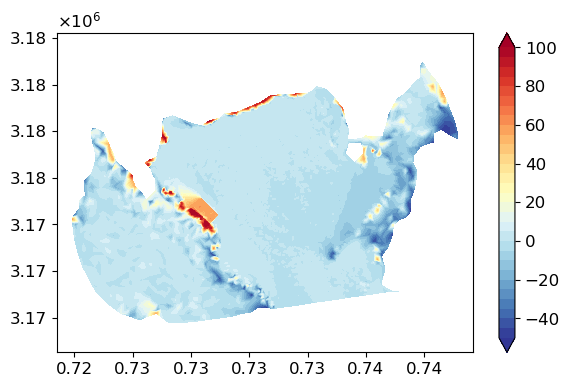

In [23]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
from matplotlib.ticker import FormatStrFormatter, FuncFormatter

# =========================
# File paths
# =========================
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_fringing_reef_v1.sw - Result Files\west_side_fringing_reef_1.5m_v2.dfsu"

dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

item_name = "Wave power, p"
target_time = np.datetime64("2017-08-26T02:30:00")

threshold = 30.0   # percent reduction threshold

# =========================
# Open and read files
# =========================
dfs_reef = mikeio.open(dfsu_reef)
dfs_no_reef = mikeio.open(dfsu_no_reef)

ds_reef = dfs_reef.read(items=[item_name])
ds_no_reef = dfs_no_reef.read(items=[item_name])

p_reef_all = ds_reef[item_name]
p_no_reef_all = ds_no_reef[item_name]

# =========================
# Use reef mesh as reference grid
# =========================
geom_reef = p_reef_all.geometry
xy_reef = geom_reef.element_coordinates[:, :2]

# Interpolate no-reef result onto reef mesh
elem_ids, weights = p_no_reef_all.geometry.get_2d_interpolant(
    xy_reef,
    n_nearest=3,
    extrapolate=False
)

def interp_no_reef_to_reef_mesh(da_no_reef_t):
    return da_no_reef_t.geometry.interp2d(
        da_no_reef_t,
        elem_ids,
        weights
    ).flatten()

# =========================
# Calculate ΔP on reef mesh
# =========================
time_index = np.argmin(np.abs(ds_reef.time.values - target_time))
selected_time = ds_reef.time.values[time_index]

p_rf = p_reef_all.isel(time=time_index).to_numpy().flatten()
p_no_interp = interp_no_reef_to_reef_mesh(
    p_no_reef_all.isel(time=time_index)
)

# Avoid division by zero
p_no_safe = np.where(p_no_interp > 1e-6, p_no_interp, np.nan)

# ΔP = (P_no_reef - P_reef) / P_no_reef * 100
delta_p = ((p_no_safe - p_rf) / p_no_safe) * 100

print("Selected timestep:", selected_time)
print("Mean ΔP (%):", np.nanmean(delta_p))
print("Max ΔP (%):", np.nanmax(delta_p))
print("Min ΔP (%):", np.nanmin(delta_p))

# =========================
# Area where ΔP > 20% using reef mesh element area
# =========================
element_area = geom_reef.get_element_area()

mask_gt20 = np.isfinite(delta_p) & (delta_p > threshold)

area_gt20_m2 = np.nansum(element_area[mask_gt20])
area_gt20_km2 = area_gt20_m2 / 1e6

total_valid_area_m2 = np.nansum(element_area[np.isfinite(delta_p)])
total_valid_area_km2 = total_valid_area_m2 / 1e6

percent_domain_gt20 = (area_gt20_m2 / total_valid_area_m2) * 100

print("\nArea with ΔP > 30% using reef mesh area:")
print(f"  {area_gt20_m2:,.2f} m²")
print(f"  {area_gt20_km2:,.4f} km²")
print(f"  {percent_domain_gt20:.2f}% of valid reef-mesh domain")

# =========================
# Smooth spatial footprint plot on reef mesh
# =========================
x = xy_reef[:, 0]
y = xy_reef[:, 1]
z = delta_p.copy()

valid = np.isfinite(z)
valid &= (z >= -50) & (z <= 100)

x_valid = x[valid]
y_valid = y[valid]
z_valid = z[valid]

triang = tri.Triangulation(x_valid, y_valid)

# Mask large triangles to avoid interpolation over land/gaps
triangles = triang.triangles

xtri = x_valid[triangles]
ytri = y_valid[triangles]

edge1 = np.sqrt((xtri[:, 0] - xtri[:, 1])**2 + (ytri[:, 0] - ytri[:, 1])**2)
edge2 = np.sqrt((xtri[:, 1] - xtri[:, 2])**2 + (ytri[:, 1] - ytri[:, 2])**2)
edge3 = np.sqrt((xtri[:, 2] - xtri[:, 0])**2 + (ytri[:, 2] - ytri[:, 0])**2)

max_edge = np.maximum.reduce([edge1, edge2, edge3])
triang.set_mask(max_edge > 600)

# =========================
# Plot
# =========================
tick_size = 12

plt.figure(figsize=(6, 4))

levels = np.linspace(-50, 100, 31)

cf = plt.tricontourf(
    triang,
    z_valid,
    levels=levels,
    cmap="RdYlBu_r",
    extend="both"
)

cbar = plt.colorbar(cf)
cbar.ax.tick_params(labelsize=tick_size)
cbar.ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
cbar.update_ticks()

ax = plt.gca()
ax.tick_params(axis="both", labelsize=tick_size)

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1e6:.2f}"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{y/1e6:.2f}"))

ax.text(
    0.0, 1.01,
    r"$\times10^{6}$",
    transform=ax.transAxes,
    fontsize=tick_size,
    ha="left",
    va="bottom"
)

plt.axis("equal")
plt.tight_layout()
plt.show()
